# CD algorithms on a fixed random ER graph: final score vs SHD

?? notebook ?? `test_cd_A_mec_score_relation.ipynb` ??? ER ?? notebook??????????? ER ????????????????????? `score` ??? `SHD` ????

???

- ?????????? `dataset_seed` ??
- ?????? `algo_master_seed` ????? `algo_seed` ??
- ?????`cd_A_epoch`?`cd_A`?`cd_B`?`cd_BOmega`
- ?? `cd_A` ? noepoch ???? `T_a_noepoch=None`????? `epochs_a * d(d+1)/2`
- ??????????????????? `score` ? `SHD`?????????? objective ?????
- `SHD` ?????????????`sum(abs(G_true - G_est))`


In [17]:
import os
import sys
import time
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    from scipy.stats import pearsonr, spearmanr
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'synthetic_dataset.py').exists() and (candidate / 'coordinate_descent').exists():
            return candidate
    raise RuntimeError('Cannot locate repo root from current working directory.')


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

from synthetic_dataset import SyntheticDataset
from MEC import is_in_markov_equiv_class
from coordinate_descent.coordinate0 import dag_coordinate_descent_l0 as cd_A_noepoch
from coordinate_descent.coordinate0 import dag_coordinate_descent_l0_epoch as cd_A_epoch
from coordinate_descent.coordinate0 import f as cd_A_objective
from coordinate_descent.cd_B import dag_coordinate_descent_B_epoch as cd_B_epoch
from coordinate_descent.cd_B import f_B as cd_B_objective
from coordinate_descent.cd_B_Omega import dag_coordinate_descent_BOmega_epoch as cd_BOmega_epoch
from coordinate_descent.cd_B_Omega import ell as cd_BOmega_objective

print('REPO_ROOT =', REPO_ROOT)
print('HAS_SCIPY =', HAS_SCIPY)


REPO_ROOT = C:\Users\super\DAG
HAS_SCIPY = True


In [18]:
CFG = {
    'selected_algorithms': ['cd_A'],  # options: 'cd_A_epoch', 'cd_A', 'cd_B', 'cd_BOmega'
    'n_trials': 100,
    'dataset_seed': 20260406,
    'algo_master_seed': 20260407,
    'n_samples': 30000,
    'd': 30,
    'degree': 2.0,
    'noise_type': 'gaussian_nv',
    'b_scale': 1.0,
    'threshold': 0.05,
    'epochs_a': 500,
    'T_a_noepoch': 100000,
    'epochs_b': 500,
    'epochs_bomega': 500,
    'lambda_l0': 0.1,
    'tol': 1e-4,
    'patience': 100,
    'min_epochs': 100,
    'k': None,
    'dag_tol': 1e-8,
    'eps_omega': 1e-8,
    'save_results': True,
}

CFG


{'selected_algorithms': ['cd_A'],
 'n_trials': 100,
 'dataset_seed': 20260406,
 'algo_master_seed': 20260407,
 'n_samples': 30000,
 'd': 30,
 'degree': 2.0,
 'noise_type': 'gaussian_nv',
 'b_scale': 1.0,
 'threshold': 0.05,
 'epochs_a': 500,
 'T_a_noepoch': 100000,
 'epochs_b': 500,
 'epochs_bomega': 500,
 'lambda_l0': 0.1,
 'tol': 0.0001,
 'patience': 100,
 'min_epochs': 100,
 'k': None,
 'dag_tol': 1e-08,
 'eps_omega': 1e-08,
 'save_results': True}

In [19]:
SUPPORTED_ALGORITHMS = ('cd_A_epoch', 'cd_A', 'cd_B', 'cd_BOmega')
OBJECTIVE_NAMES = {
    'cd_A_epoch': 'f_A',
    'cd_A': 'f_A',
    'cd_B': 'f_B',
    'cd_BOmega': 'ell',
}


def weight_to_binary_adj(W: np.ndarray, threshold: float = 0.05) -> np.ndarray:
    G = (np.abs(W) > threshold).astype(int)
    np.fill_diagonal(G, 0)
    return G


def shd_score(G_true: np.ndarray, G_est: np.ndarray) -> int:
    G_true = np.asarray(G_true, dtype=int)
    G_est = np.asarray(G_est, dtype=int)
    return int(np.sum(np.abs(G_true - G_est)))


def compute_noise_variances(noise_meta, d: int) -> np.ndarray:
    noise_meta = np.asarray(noise_meta, dtype=float)
    if noise_meta.ndim == 0:
        var_diag = np.full(d, float(noise_meta) ** 2)
    elif noise_meta.ndim == 1:
        if noise_meta.size == d:
            var_diag = np.square(noise_meta.astype(float))
        else:
            var_diag = np.full(d, float(np.mean(noise_meta)) ** 2)
    else:
        var_diag = np.var(noise_meta, axis=0, ddof=1)
    return np.maximum(var_diag, 1e-12)


def build_true_A_from_variances(B_true: np.ndarray, var_diag: np.ndarray) -> np.ndarray:
    return (np.eye(B_true.shape[0]) - B_true) @ np.diag(1.0 / np.sqrt(var_diag))


def compute_true_scores(B_true: np.ndarray, noise_meta, S: np.ndarray) -> dict:
    d = B_true.shape[0]
    var_diag = compute_noise_variances(noise_meta, d)
    Omega_true = np.diag(var_diag)
    A_true = build_true_A_from_variances(B_true, var_diag)
    return {
        'A_true': A_true,
        'Omega_true': Omega_true,
        'var_diag': var_diag,
        'true_scores': {
            'cd_A_epoch': float(cd_A_objective(A_true, S)),
            'cd_A': float(cd_A_objective(A_true, S)),
            'cd_B': float(cd_B_objective(B_true, S)),
            'cd_BOmega': float(cd_BOmega_objective(B_true, Omega_true, S)),
        },
    }


def generate_er_trial(cfg: dict, seed: int) -> dict:
    dataset = SyntheticDataset(
        n=cfg['n_samples'],
        d=cfg['d'],
        graph_type='ER',
        degree=cfg['degree'],
        noise_type=cfg['noise_type'],
        B_scale=cfg['b_scale'],
        seed=int(seed),
    )
    X = dataset.X
    S = X.T @ X / X.shape[0]
    B_true = np.asarray(dataset.B, dtype=float)
    G_true = weight_to_binary_adj(B_true, threshold=0.0)
    true_stats = compute_true_scores(B_true, dataset.N, S)
    return {
        'dataset_seed': int(seed),
        'X': X,
        'S': S,
        'B_true': B_true,
        'G_true': G_true,
        'A_true': true_stats['A_true'],
        'Omega_true': true_stats['Omega_true'],
        'var_diag': true_stats['var_diag'],
        'true_scores': true_stats['true_scores'],
        'n_edges_true': int(G_true.sum()),
    }


def get_budget_for_algorithm(cfg: dict, algorithm: str) -> tuple[int, str]:
    if algorithm == 'cd_A_epoch':
        return int(cfg['epochs_a']), 'epoch'
    if algorithm == 'cd_A':
        T_a_noepoch = cfg.get('T_a_noepoch')
        if T_a_noepoch is None:
            d = int(cfg['d'])
            T_a_noepoch = int(cfg['epochs_a']) * (d * (d + 1) // 2)
        return int(T_a_noepoch), 'iter'
    if algorithm == 'cd_B':
        return int(cfg['epochs_b']), 'epoch'
    if algorithm == 'cd_BOmega':
        return int(cfg['epochs_bomega']), 'epoch'
    raise ValueError(f'Unsupported algorithm: {algorithm}')


def run_algorithm_trial(trial: dict, cfg: dict, algorithm: str, seed: int) -> dict:
    S = trial['S']
    G_true = trial['G_true']
    d = S.shape[0]
    budget_requested, budget_type = get_budget_for_algorithm(cfg, algorithm)

    t0 = time.perf_counter()

    if algorithm == 'cd_A_epoch':
        _, G_est, score_end, history = cd_A_epoch(
            S=S,
            n_epochs=budget_requested,
            seed=int(seed),
            threshold=cfg['threshold'],
            lambda_l0=cfg['lambda_l0'],
            tol=cfg['tol'],
            patience=cfg['patience'],
            min_epochs=cfg['min_epochs'],
            verbose=False,
        )
    elif algorithm == 'cd_A':
        _, G_est, score_end, history = cd_A_noepoch(
            S=S,
            T=budget_requested,
            seed=int(seed),
            threshold=cfg['threshold'],
            lambda_l0=cfg['lambda_l0'],
            return_history=True,
        )
    elif algorithm == 'cd_B':
        _, G_est, score_end, history, _ = cd_B_epoch(
            S=S,
            n_epochs=budget_requested,
            seed=int(seed),
            threshold=cfg['threshold'],
            lambda_l0=cfg['lambda_l0'],
            k=cfg['k'],
            dag_tol=cfg['dag_tol'],
            tol=cfg['tol'],
            patience=cfg['patience'],
            min_epochs=cfg['min_epochs'],
            verbose=False,
        )
    elif algorithm == 'cd_BOmega':
        _, G_est, score_end, history, _ = cd_BOmega_epoch(
            S=S,
            Omega=np.eye(d),
            n_epochs=budget_requested,
            seed=int(seed),
            threshold=cfg['threshold'],
            lambda_l0=cfg['lambda_l0'],
            k=cfg['k'],
            dag_tol=cfg['dag_tol'],
            tol=cfg['tol'],
            patience=cfg['patience'],
            min_epochs=cfg['min_epochs'],
            eps_omega=cfg['eps_omega'],
            verbose=False,
        )
    else:
        raise ValueError(f'Unsupported algorithm: {algorithm}')

    runtime_sec = time.perf_counter() - t0

    return {
        'objective_name': OBJECTIVE_NAMES[algorithm],
        'score': float(score_end),
        'true_score': float(trial['true_scores'][algorithm]),
        'score_gap_true': float(score_end - trial['true_scores'][algorithm]),
        'mec_match': int(is_in_markov_equiv_class(G_true, G_est)),
        'shd': int(shd_score(G_true, G_est)),
        'n_edges_true': int(trial['n_edges_true']),
        'n_edges_est': int(np.sum(G_est)),
        'runtime_sec': float(runtime_sec),
        'budget_type': budget_type,
        'budget_requested': int(budget_requested),
        'n_steps_run': int(len(history)),
    }


In [20]:
selected_algorithms = list(CFG['selected_algorithms'])
unknown_algorithms = sorted(set(selected_algorithms) - set(SUPPORTED_ALGORITHMS))
if unknown_algorithms:
    raise ValueError(f'Unsupported algorithms: {unknown_algorithms}')

fixed_trial = generate_er_trial(CFG, int(CFG['dataset_seed']))
rng = np.random.default_rng(CFG['algo_master_seed'])
algo_seeds = rng.integers(0, 10**9, size=CFG['n_trials'])
rows: List[Dict[str, float]] = []

print(
    'Fixed ER dataset:',
    f"dataset_seed={fixed_trial['dataset_seed']}",
    f"d={CFG['d']}",
    f"n_samples={CFG['n_samples']}",
    f"degree={CFG['degree']}",
    f"true_edges={fixed_trial['n_edges_true']}",
)
print('Selected algorithms:', selected_algorithms)
print('True scores under the fixed dataset:')
for algorithm in selected_algorithms:
    budget_requested, budget_type = get_budget_for_algorithm(CFG, algorithm)
    print(
        f"  - {algorithm:<10} objective={OBJECTIVE_NAMES[algorithm]:<4} "
        f"true_score={fixed_trial['true_scores'][algorithm]:.6f} "
        f"budget=({budget_type}={budget_requested})"
    )

for algorithm in selected_algorithms:
    for trial_id, algo_seed in enumerate(algo_seeds, start=1):
        result = run_algorithm_trial(fixed_trial, CFG, algorithm, int(algo_seed))

        rows.append({
            'trial_id': int(trial_id),
            'dataset_seed': int(fixed_trial['dataset_seed']),
            'algo_seed': int(algo_seed),
            'algorithm': algorithm,
            'objective_name': result['objective_name'],
            'budget_type': result['budget_type'],
            'budget_requested': int(result['budget_requested']),
            'd': int(CFG['d']),
            'n_samples': int(CFG['n_samples']),
            'degree': float(CFG['degree']),
            'noise_type': CFG['noise_type'],
            'b_scale': float(CFG['b_scale']),
            'threshold': float(CFG['threshold']),
            'lambda_l0': float(CFG['lambda_l0']),
            'score': float(result['score']),
            'true_score': float(result['true_score']),
            'score_gap_true': float(result['score_gap_true']),
            'mec_match': int(result['mec_match']),
            'shd': int(result['shd']),
            'n_edges_true': int(result['n_edges_true']),
            'n_edges_est': int(result['n_edges_est']),
            'runtime_sec': float(result['runtime_sec']),
            'n_steps_run': int(result['n_steps_run']),
        })

        if trial_id <= 3 or trial_id % 20 == 0:
            print(
                f"[{algorithm}][trial {trial_id:03d}/{CFG['n_trials']}] algo_seed={int(algo_seed)} "
                f"score={result['score']:.6f} "
                f"gap={result['score_gap_true']:.6f} "
                f"shd={result['shd']} mec={result['mec_match']} "
                f"rt={result['runtime_sec']:.3f}s"
            )

df_trials = pd.DataFrame(rows)
print('Total rows:', len(df_trials))
display(df_trials.head())


Fixed ER dataset: dataset_seed=20260406 d=30 n_samples=30000 degree=2.0 true_edges=30
Selected algorithms: ['cd_A']
True scores under the fixed dataset:
  - cd_A       objective=f_A  true_score=61.515713 budget=(iter=100000)
[cd_A][trial 001/100] algo_seed=18044244 score=56.663970 gap=-4.851744 shd=8 mec=0 rt=47.945s
[cd_A][trial 002/100] algo_seed=604916791 score=57.171504 gap=-4.344209 shd=16 mec=0 rt=47.247s
[cd_A][trial 003/100] algo_seed=837616598 score=57.100682 gap=-4.415031 shd=27 mec=0 rt=50.913s
[cd_A][trial 020/100] algo_seed=287248299 score=56.929461 gap=-4.586252 shd=27 mec=0 rt=44.803s
[cd_A][trial 040/100] algo_seed=885062436 score=57.158620 gap=-4.357093 shd=32 mec=0 rt=77.894s
[cd_A][trial 060/100] algo_seed=478997247 score=56.711867 gap=-4.803847 shd=13 mec=0 rt=46.486s
[cd_A][trial 080/100] algo_seed=138715430 score=56.663679 gap=-4.852035 shd=16 mec=0 rt=46.413s
[cd_A][trial 100/100] algo_seed=269600123 score=57.171816 gap=-4.343898 shd=20 mec=0 rt=45.415s
Total row

,trial_id,dataset_seed,algo_seed,algorithm,objective_name,budget_type,budget_requested,d,n_samples,degree,...,lambda_l0,score,true_score,score_gap_true,mec_match,shd,n_edges_true,n_edges_est,runtime_sec,n_steps_run
0,1,20260406,18044244,cd_A,f_A,iter,100000,30,30000,2.0,...,0.1,56.663970,61.515713,-4.851744,0,8,30,34,47.944850,100000
1,2,20260406,604916791,cd_A,f_A,iter,100000,30,30000,2.0,...,0.1,57.171504,61.515713,-4.344209,0,16,30,36,47.246805,100000
2,3,20260406,837616598,cd_A,f_A,iter,100000,30,30000,2.0,...,0.1,57.100682,61.515713,-4.415031,0,27,30,41,50.913453,100000
3,4,20260406,805844143,cd_A,f_A,iter,100000,30,30000,2.0,...,0.1,57.201360,61.515713,-4.314353,0,21,30,35,46.527660,100000
4,5,20260406,156042563,cd_A,f_A,iter,100000,30,30000,2.0,...,0.1,58.053622,61.515713,-3.462091,0,31,30,45,47.028170,100000


In [21]:
overall_summary = (
    df_trials.groupby(['algorithm', 'objective_name', 'budget_type', 'budget_requested'], as_index=False)
    .agg(
        trials=('score', 'size'),
        score_mean=('score', 'mean'),
        score_std=('score', 'std'),
        true_score_mean=('true_score', 'mean'),
        score_gap_true_mean=('score_gap_true', 'mean'),
        score_gap_true_std=('score_gap_true', 'std'),
        shd_mean=('shd', 'mean'),
        shd_std=('shd', 'std'),
        mec_rate=('mec_match', 'mean'),
        runtime_sec_mean=('runtime_sec', 'mean'),
        n_steps_run_mean=('n_steps_run', 'mean'),
    )
    .sort_values('algorithm')
    .reset_index(drop=True)
)

summary_by_shd = (
    df_trials.groupby(['algorithm', 'shd'], as_index=False)
    .agg(
        objective_name=('objective_name', 'first'),
        budget_type=('budget_type', 'first'),
        budget_requested=('budget_requested', 'first'),
        n=('score', 'size'),
        score_mean=('score', 'mean'),
        score_std=('score', 'std'),
        true_score_mean=('true_score', 'mean'),
        score_gap_true_mean=('score_gap_true', 'mean'),
        score_gap_true_std=('score_gap_true', 'std'),
        mec_rate=('mec_match', 'mean'),
    )
    .sort_values(['algorithm', 'shd'])
    .reset_index(drop=True)
)

print('Overall summary by algorithm:')
display(overall_summary)
print('Mean metrics per SHD within each algorithm:')
display(summary_by_shd)


Overall summary by algorithm:


,algorithm,objective_name,budget_type,budget_requested,trials,score_mean,score_std,true_score_mean,score_gap_true_mean,score_gap_true_std,shd_mean,shd_std,mec_rate,runtime_sec_mean,n_steps_run_mean
0,cd_A,f_A,iter,100000,100,57.274372,0.463955,61.515713,-4.241342,0.463955,26.6,8.438727,0.0,53.542846,100000.0


Mean metrics per SHD within each algorithm:


,algorithm,shd,objective_name,budget_type,budget_requested,n,score_mean,score_std,true_score_mean,score_gap_true_mean,score_gap_true_std,mec_rate
0,cd_A,7,f_A,iter,100000,1,56.664015,NaN,61.515713,-4.851698,NaN,0.0
1,cd_A,8,f_A,iter,100000,1,56.663970,NaN,61.515713,-4.851744,NaN,0.0
2,cd_A,12,f_A,iter,100000,2,57.146110,0.027878,61.515713,-4.369604,0.027878,0.0
3,cd_A,13,f_A,iter,100000,2,56.729534,0.024985,61.515713,-4.786180,0.024985,0.0
4,cd_A,14,f_A,iter,100000,2,56.811365,0.208495,61.515713,-4.704348,0.208495,0.0
5,cd_A,15,f_A,iter,100000,2,56.974191,0.024474,61.515713,-4.541523,0.024474,0.0
6,cd_A,16,f_A,iter,100000,3,56.907319,0.254535,61.515713,-4.608394,0.254535,0.0
7,cd_A,17,f_A,iter,100000,1,57.041214,NaN,61.515713,-4.474499,NaN,0.0
8,cd_A,18,f_A,iter,100000,2,57.161310,0.471755,61.515713,-4.354404,0.471755,0.0
9,cd_A,19,f_A,iter,100000,1,57.227354,NaN,61.515713,-4.288360,NaN,0.0


In [1]:
algorithms = overall_summary['algorithm'].tolist()
n_algorithms = len(algorithms)
ncols = 1 if n_algorithms == 1 else 2
nrows = int(np.ceil(n_algorithms / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4.8 * nrows), constrained_layout=True, squeeze=False)

for ax, algorithm in zip(axes.flat, algorithms):
    sub = df_trials[df_trials['algorithm'] == algorithm]
    sub_summary = summary_by_shd[summary_by_shd['algorithm'] == algorithm]
    true_score_mean = float(sub['true_score'].mean())
    shd_x = sub_summary['shd'].to_numpy()
    score_mean = sub_summary['score_mean'].to_numpy()
    score_std = sub_summary['score_std'].fillna(0.0).to_numpy()

    for mec_value, color in [(0, 'tab:orange'), (1, 'tab:blue')]:
        mec_sub = sub[sub['mec_match'] == mec_value]
        if len(mec_sub) == 0:
            continue
        ax.scatter(mec_sub['shd'], mec_sub['score'], alpha=0.45, s=24, c=color, label=f'mec_match={mec_value}')

    ax.errorbar(
        shd_x,
        score_mean,
        yerr=score_std,
        color='black',
        marker='D',
        markersize=6,
        linewidth=1.5,
        capsize=4,
        zorder=5,
        label='mean score per SHD',
    )
    ax.axhline(true_score_mean, color='red', linestyle='--', linewidth=1.6, label=f'mean true_score={true_score_mean:.4f}')
    budget_type = sub_summary['budget_type'].iloc[0]
    budget_requested = int(sub_summary['budget_requested'].iloc[0])
    objective_name = sub_summary['objective_name'].iloc[0]
    ax.set_title(f'{algorithm} ({objective_name}, {budget_type}={budget_requested})')
    ax.set_xlabel('SHD')
    ax.set_ylabel('final score')
    ax.set_ylim(bottom=min(56.4, 59.2))
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

for ax in axes.flat[n_algorithms:]:
    ax.axis('off')

plt.show()


NameError: name 'overall_summary' is not defined

In [23]:
correlation_summary = pd.DataFrame()

if HAS_SCIPY:
    corr_rows = []
    for algorithm, sub in df_trials.groupby('algorithm'):
        rho_score, p_score = spearmanr(sub['shd'], sub['score'], nan_policy='omit')
        rho_gap, p_gap = spearmanr(sub['shd'], sub['score_gap_true'], nan_policy='omit')

        if sub['shd'].nunique() > 1 and len(sub) >= 2:
            r_score, p_r_score = pearsonr(sub['shd'], sub['score'])
            r_gap, p_r_gap = pearsonr(sub['shd'], sub['score_gap_true'])
        else:
            r_score, p_r_score = np.nan, np.nan
            r_gap, p_r_gap = np.nan, np.nan

        corr_rows.append({
            'algorithm': algorithm,
            'spearman_rho_score': float(rho_score),
            'spearman_p_score': float(p_score),
            'spearman_rho_gap': float(rho_gap),
            'spearman_p_gap': float(p_gap),
            'pearson_r_score': float(r_score) if np.isfinite(r_score) else np.nan,
            'pearson_p_score': float(p_r_score) if np.isfinite(p_r_score) else np.nan,
            'pearson_r_gap': float(r_gap) if np.isfinite(r_gap) else np.nan,
            'pearson_p_gap': float(p_r_gap) if np.isfinite(p_r_gap) else np.nan,
        })

        print(f'[{algorithm}] Spearman correlation(SHD, score): rho={rho_score:.4f}, p={p_score:.4g}')
        print(f'[{algorithm}] Spearman correlation(SHD, score_gap_true): rho={rho_gap:.4f}, p={p_gap:.4g}')
        if np.isfinite(r_score):
            print(f'[{algorithm}] Pearson correlation(SHD, score): r={r_score:.4f}, p={p_r_score:.4g}')
            print(f'[{algorithm}] Pearson correlation(SHD, score_gap_true): r={r_gap:.4f}, p={p_r_gap:.4g}')
        print()

    correlation_summary = pd.DataFrame(corr_rows)
    print('Correlation summary by algorithm:')
    display(correlation_summary)
else:
    print('scipy ?????????????')


[cd_A] Spearman correlation(SHD, score): rho=0.6064, p=2.281e-11
[cd_A] Spearman correlation(SHD, score_gap_true): rho=0.6064, p=2.281e-11
[cd_A] Pearson correlation(SHD, score): r=0.5218, p=2.59e-08
[cd_A] Pearson correlation(SHD, score_gap_true): r=0.5218, p=2.59e-08

Correlation summary by algorithm:


,algorithm,spearman_rho_score,spearman_p_score,spearman_rho_gap,spearman_p_gap,pearson_r_score,pearson_p_score,pearson_r_gap,pearson_p_gap
0,cd_A,0.606442,2.280737e-11,0.606442,2.280737e-11,0.521795,2.590221e-08,0.521795,2.590221e-08


In [24]:
if CFG['save_results']:
    out_dir = REPO_ROOT / 'experiments' / 'results'
    out_dir.mkdir(parents=True, exist_ok=True)

    trials_csv = out_dir / 'er_cd_score_shd_relation_trials.csv'
    overall_csv = out_dir / 'er_cd_score_shd_relation_overall_summary.csv'
    by_shd_csv = out_dir / 'er_cd_score_shd_relation_summary_by_shd.csv'
    corr_csv = out_dir / 'er_cd_score_shd_relation_correlations.csv'

    df_trials.to_csv(trials_csv, index=False, encoding='utf-8-sig')
    overall_summary.to_csv(overall_csv, index=False, encoding='utf-8-sig')
    summary_by_shd.to_csv(by_shd_csv, index=False, encoding='utf-8-sig')
    if not correlation_summary.empty:
        correlation_summary.to_csv(corr_csv, index=False, encoding='utf-8-sig')

    print('Saved:')
    print(' -', trials_csv)
    print(' -', overall_csv)
    print(' -', by_shd_csv)
    if not correlation_summary.empty:
        print(' -', corr_csv)


Saved:
 - C:\Users\super\DAG\experiments\results\er_cd_score_shd_relation_trials.csv
 - C:\Users\super\DAG\experiments\results\er_cd_score_shd_relation_overall_summary.csv
 - C:\Users\super\DAG\experiments\results\er_cd_score_shd_relation_summary_by_shd.csv
 - C:\Users\super\DAG\experiments\results\er_cd_score_shd_relation_correlations.csv


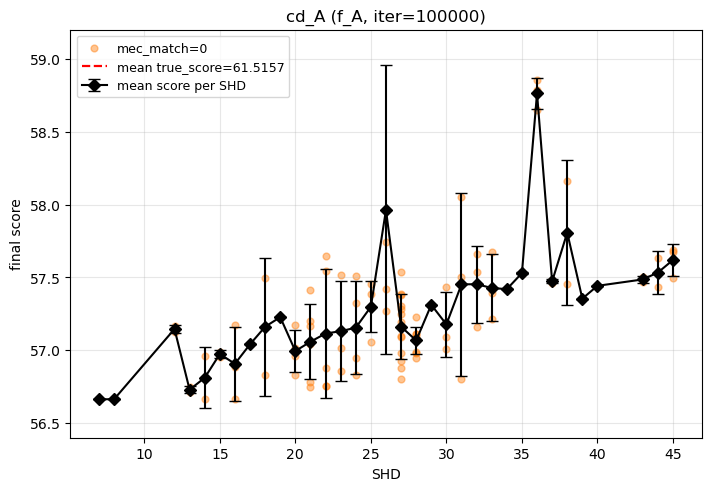

In [3]:
# ---- 从已保存的 CSV 重新加载数据并画图 ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

out_dir = Path(r'C:\Users\super\DAG\experiments\results')
df_trials = pd.read_csv(out_dir / 'er_cd_score_shd_relation_trials.csv')
overall_summary = pd.read_csv(out_dir / 'er_cd_score_shd_relation_overall_summary.csv')
summary_by_shd = pd.read_csv(out_dir / 'er_cd_score_shd_relation_summary_by_shd.csv')

algorithms = overall_summary['algorithm'].tolist()
n_algorithms = len(algorithms)
ncols = 1 if n_algorithms == 1 else 2
nrows = int(np.ceil(n_algorithms / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4.8 * nrows), constrained_layout=True, squeeze=False)

for ax, algorithm in zip(axes.flat, algorithms):
    sub = df_trials[df_trials['algorithm'] == algorithm]
    sub_summary = summary_by_shd[summary_by_shd['algorithm'] == algorithm]
    true_score_mean = float(sub['true_score'].mean())
    shd_x = sub_summary['shd'].to_numpy()
    score_mean = sub_summary['score_mean'].to_numpy()
    score_std = sub_summary['score_std'].fillna(0.0).to_numpy()

    for mec_value, color in [(0, 'tab:orange'), (1, 'tab:blue')]:
        mec_sub = sub[sub['mec_match'] == mec_value]
        if len(mec_sub) == 0:
            continue
        ax.scatter(mec_sub['shd'], mec_sub['score'], alpha=0.45, s=24, c=color, label=f'mec_match={mec_value}')

    ax.errorbar(
        shd_x,
        score_mean,
        yerr=score_std,
        color='black',
        marker='D',
        markersize=6,
        linewidth=1.5,
        capsize=4,
        zorder=5,
        label='mean score per SHD',
    )
    ax.axhline(true_score_mean, color='red', linestyle='--', linewidth=1.6, label=f'mean true_score={true_score_mean:.4f}')
    budget_type = sub_summary['budget_type'].iloc[0]
    budget_requested = int(sub_summary['budget_requested'].iloc[0])
    objective_name = sub_summary['objective_name'].iloc[0]
    
    ax.set_ylim(56.4, 59.2)
    ax.set_title(f'{algorithm} ({objective_name}, {budget_type}={budget_requested})')
    ax.set_xlabel('SHD')
    ax.set_ylabel('final score')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

for ax in axes.flat[n_algorithms:]:
    ax.axis('off')

plt.show()